In [1]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

In [2]:
# Load the BTS airport data
file_path = "db28seg.dd.wac.202507.202606.asc"

df = pd.read_csv(
    file_path,
    sep="|",
    header=None
)

# Check the size of the original dataset
print("Original data shape:", df.shape)

# Look at the first few rows to make sure it loaded correctly
df.head()

Original data shape: (460197, 29)


,0,1,2,3,4,5,6,7,8,9,...,19,20,21,22,23,24,25,26,27,28
0,2025,8,01A,30001,1,"Afognak Lake, AK",A43,30056,1,"Kodiak Island, AK",...,0,750,5,2,0,0,25,23,1,NaN
1,2025,8,01A,30001,1,"Afognak Lake, AK",A43,30056,1,"Kodiak Island, AK",...,0,7200,36,6,0,0,147,133,1,NaN
2,2025,9,01A,30001,1,"Afognak Lake, AK",A43,30056,1,"Kodiak Island, AK",...,0,4800,24,13,144,0,200,160,1,NaN
3,2026,5,01A,30001,1,"Afognak Lake, AK",A43,30056,1,"Kodiak Island, AK",...,0,1500,10,2,0,0,39,34,1,NaN
4,2026,5,01A,30001,1,"Afognak Lake, AK",A43,30056,1,"Kodiak Island, AK",...,0,1200,6,0,0,0,24,19,1,NaN


In [3]:
# Rename the columns that I will use for this project
# I mainly need the date, origin airport, and destination airport
df = df.rename(columns={
    0: "Year",
    1: "Month",
    2: "Origin",
    3: "Origin_ID",
    4: "Origin_WAC",
    5: "Origin_City",
    6: "Destination",
    7: "Destination_ID",
    8: "Destination_WAC",
    9: "Destination_City"
})

# Check the columns I will be working with
df[
    [
        "Year",
        "Month",
        "Origin",
        "Origin_City",
        "Destination",
        "Destination_City"
    ]
].head()

,Year,Month,Origin,Origin_City,Destination,Destination_City
0,2025,8,01A,"Afognak Lake, AK",A43,"Kodiak Island, AK"
1,2025,8,01A,"Afognak Lake, AK",A43,"Kodiak Island, AK"
2,2025,9,01A,"Afognak Lake, AK",A43,"Kodiak Island, AK"
3,2026,5,01A,"Afognak Lake, AK",A43,"Kodiak Island, AK"
4,2026,5,01A,"Afognak Lake, AK",A43,"Kodiak Island, AK"


In [4]:
# For my project I only want to look at flights reported in June 2026
june_2026 = df[
    (df["Year"] == 2026) &
    (df["Month"] == 6)
].copy()

# Check how many records are left
print("June 2026 segment records:", len(june_2026))

June 2026 segment records: 38287


In [5]:
# Check if there are any rows where the origin and destination are the same
self_loops = june_2026[
    june_2026["Origin"] == june_2026["Destination"]
]

print("Self-loop records:", len(self_loops))

# Remove the self-loops
june_clean = june_2026[
    june_2026["Origin"] != june_2026["Destination"]
].copy()

print("Rows after removing self-loops:", len(june_clean))

Self-loop records: 394
Rows after removing self-loops: 37893


In [6]:
# Put the airport codes in the same order for every pair
june_clean["Airport_A"] = june_clean[
    ["Origin", "Destination"]
].min(axis=1)

june_clean["Airport_B"] = june_clean[
    ["Origin", "Destination"]
].max(axis=1)

# Keep only one copy of each airport connection
routes = june_clean[
    ["Airport_A", "Airport_B"]
].drop_duplicates().reset_index(drop=True)

# Check how many unique routes I have
print("Unique airport connections:", len(routes))

routes.head()

Unique airport connections: 8019


,Airport_A,Airport_B
0,05A,FAI
1,06A,A43
2,09A,A43
3,09A,A50
4,1G4,BLD


In [7]:
# Create an undirected graph using NetworkX
G = nx.Graph()

# Each airport becomes a node and each route becomes an edge
G.add_edges_from(
    routes[["Airport_A", "Airport_B"]].itertuples(
        index=False,
        name=None
    )
)

# Check the size of my network
print("Number of airports:", G.number_of_nodes())
print("Number of routes:", G.number_of_edges())

Number of airports: 977
Number of routes: 8019


In [8]:
# Check if all of the airports are part of one connected group
print("Is the network connected?", nx.is_connected(G))

# Find the different connected groups in the network
components = sorted(
    nx.connected_components(G),
    key=len,
    reverse=True
)

print("Number of connected groups:", len(components))

# Check how many airports are in each group
for i, component in enumerate(components, start=1):
    print(f"Group {i}: {len(component)} airports")

Is the network connected? False
Number of connected groups: 2
Group 1: 964 airports
Group 2: 13 airports


In [9]:
# Most of the airports are in the largest group
# I will use this group for my centrality analysis
largest_component = components[0]

G_main = G.subgraph(largest_component).copy()

# Check the size of the graph I will use for the analysis
print("Airports in largest group:", G_main.number_of_nodes())
print("Routes in largest group:", G_main.number_of_edges())

Airports in largest group: 964
Routes in largest group: 7992


In [10]:
# Degree centrality shows how connected each airport is
degree_centrality = nx.degree_centrality(G_main)

betweenness_centrality = nx.betweenness_centrality(G_main)

In [11]:
# Put the centrality results into a DataFrame so they are easier to compare
results = pd.DataFrame({
    "Airport": list(G_main.nodes()),

    # This is the actual number of direct airport connections
    "Direct_Connections": [
        G_main.degree(airport)
        for airport in G_main.nodes()
    ],

    "Degree_Centrality": [
        degree_centrality[airport]
        for airport in G_main.nodes()
    ],

    "Betweenness_Centrality": [
        betweenness_centrality[airport]
        for airport in G_main.nodes()
    ]
})

# Sort the airports from highest to lowest betweenness centrality
results = results.sort_values(
    "Betweenness_Centrality",
    ascending=False
).reset_index(drop=True)

# Look at the top 10 airports
results.head(10)

,Airport,Direct_Connections,Degree_Centrality,Betweenness_Centrality
0,ANC,118,0.122534,0.327012
1,FAI,71,0.073728,0.104286
2,DEN,221,0.229491,0.102022
3,ORD,221,0.229491,0.100127
4,DFW,208,0.215992,0.058727
5,ADQ,13,0.013499,0.054736
6,IAD,150,0.155763,0.050455
7,MSP,162,0.168224,0.049822
8,SEA,115,0.119418,0.047578
9,HPN,103,0.106957,0.046444


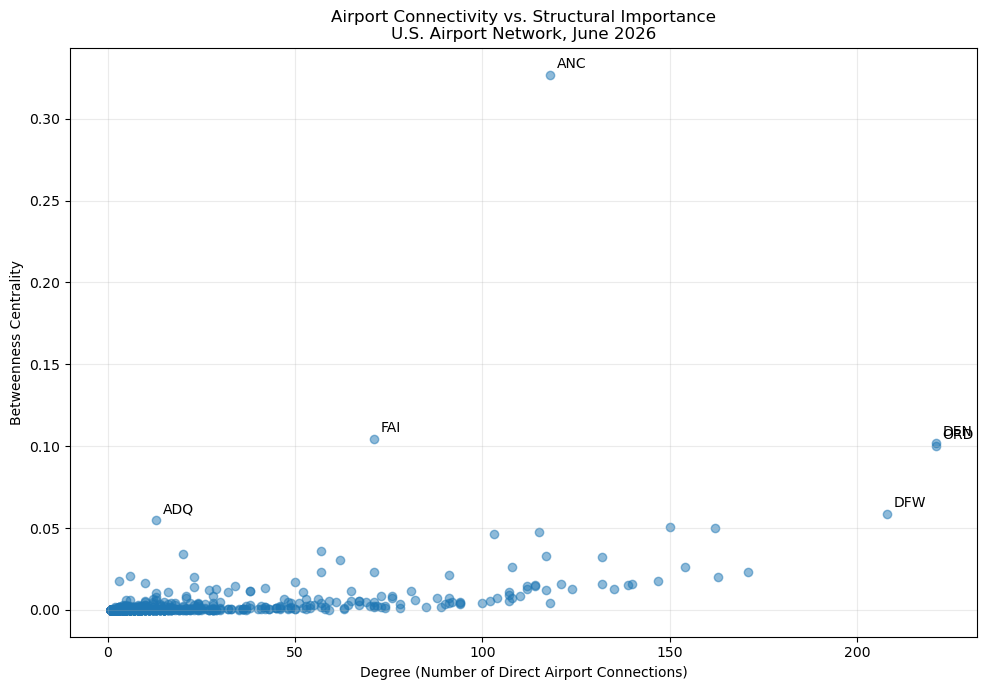

In [12]:
# Make a scatterplot to compare direct connections and betweenness centrality
plt.figure(figsize=(10, 7))

plt.scatter(
    results["Direct_Connections"],
    results["Betweenness_Centrality"],
    alpha=0.5
)

# Label some of the airports that I discuss in the article
airports_to_label = [
    "ANC",
    "FAI",
    "DEN",
    "ORD",
    "DFW",
    "ADQ"
]

for airport in airports_to_label:

    # Find the row for this airport
    row = results[
        results["Airport"] == airport
    ]

    x = row["Direct_Connections"].iloc[0]
    y = row["Betweenness_Centrality"].iloc[0]

    # Add the airport code next to its point
    plt.annotate(
        airport,
        (x, y),
        xytext=(5, 5),
        textcoords="offset points"
    )

# Add labels so the graph is easy to understand
plt.xlabel("Degree (Number of Direct Airport Connections)")
plt.ylabel("Betweenness Centrality")

plt.title(
    "Airport Connectivity vs. Structural Importance\n"
    "U.S. Airport Network, June 2026"
)

plt.grid(alpha=0.25)
plt.tight_layout()

plt.show()